In [61]:
import pandas as pd

In [62]:
import numpy as np

In [39]:
import matplotlib.pyplot as plt

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
from sklearn.metrics import precision_score, confusion_matrix, accuracy_score, recall_score

In [44]:
df = pd.read_csv('sentimentdataset.csv')

In [63]:
df = pd.read_csv('sentimentdataset.csv')

In [47]:
df['Sentiment'] = df['Sentiment'].str.strip()
le = LabelEncoder()
df['Sentiment_Enc'] = le.fit_transform(df['Sentiment'])

In [48]:
print(df.isnull().sum())

Unnamed: 0.1     0
Unnamed: 0       0
Text             0
Sentiment        0
Timestamp        0
User             0
Platform         0
Hashtags         0
Retweets         0
Likes            0
Country          0
Year             0
Month            0
Day              0
Hour             0
Sentiment_Enc    0
dtype: int64


In [49]:
print(df[['Retweets', 'Likes', 'Sentiment_Enc']].cov())

                Retweets       Likes  Sentiment_Enc
Retweets       49.861766   99.341437       8.893162
Likes          99.341437  198.523828      17.617210
Sentiment_Enc   8.893162   17.617210    2495.254519


In [50]:
X = df[['Retweets', 'Likes']]
Y = df['Sentiment_Enc']

In [51]:
xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, random_state=42)

In [52]:
scaler = StandardScaler()
xtrain = scaler.fit_transform(xtrain)
xtest = scaler.transform(xtest)

In [53]:
logreg = LogisticRegression(max_iter=2000)
logreg.fit(xtrain, ytrain)

LogisticRegression(max_iter=2000)

In [54]:
y_pred = logreg.predict(xtest)

In [55]:
y_train_pred = logreg.predict(xtrain)

In [56]:
cm = confusion_matrix(ytest, y_pred)
accuracy = accuracy_score(ytest, y_pred)
precision = precision_score(ytest, y_pred, average='weighted', zero_division=0)
recall = recall_score(ytest, y_pred, average='weighted', zero_division=0)

In [66]:
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")

Accuracy:  0.0612
Precision: 0.0098
Recall:    0.0612


In [69]:
cm = confusion_matrix(ytest, y_pred)

In [74]:
n_classes = len(le.classes_)
print(f"Number of classes: {n_classes}")

Number of classes: 191


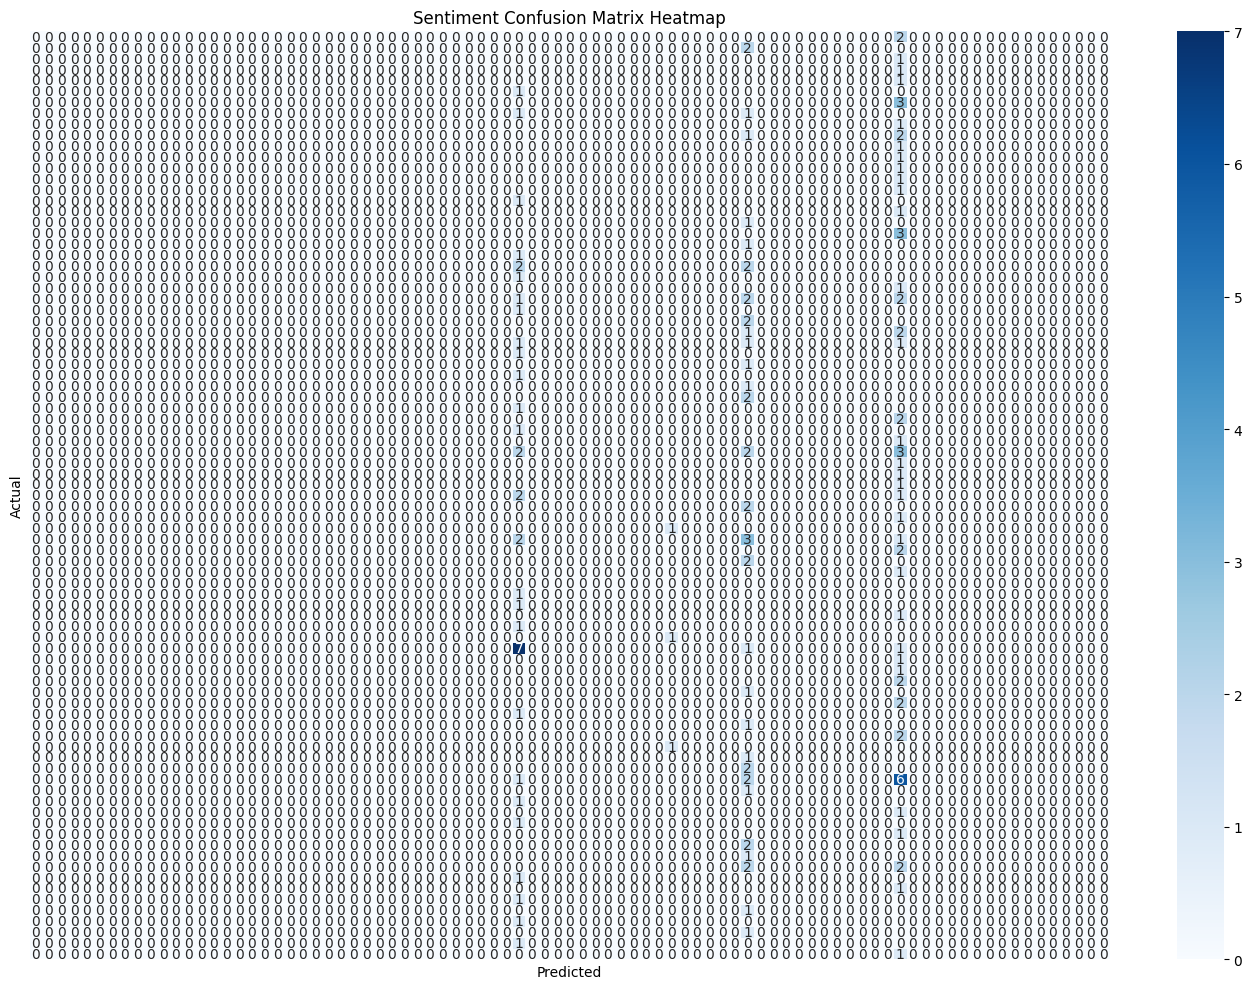

In [75]:
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_ if n_classes < 30 else False,
            yticklabels=le.classes_ if n_classes < 30 else False)
plt.title('Sentiment Confusion Matrix Heatmap')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png')